In [1]:
from google import genai
import os

client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))

response = client.models.generate_content(
    model="gemini-3.1-pro-preview", 
    contents="Hello from my Jupyter notebook!"
)

print(response.text)

Hello there! 👋 

What are we working on in the notebook today? Whether you're wrangling data with Pandas, training machine learning models, debugging some tricky Python code, or just setting up some Markdown cells, I'm here to help. 

Let me know what you need!


In [2]:
import sys
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Torch CUDA:", torch.version.cuda)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\ProgramData\anaconda3\envs\gemini_env\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\ProgramData\anaconda3\envs\gemini_env\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\ProgramData\anaconda3\envs\gemini_env\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\envs\gemini_env\Lib\site-packages\traitlets\config\application.py", line 1082, in launch_instan

Torch version: 2.2.0+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Torch CUDA: 11.8


In [3]:
import os
import re
import platform
import urllib.request
import requests

import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image
from jiwer import wer, cer

In [9]:
prompt_text_1 = "Extract all text from this image exactly as written. Preserve line breaks."

In [8]:
prompt_text_2 = """
You are an OCR specialist.

Extract every visible character from this image exactly as it appears.

Return plain text only. Preserve the original reading order, line breaks, paragraph breaks, headings, punctuation, capitalization, spelling, abbreviations, page numbers, and hyphenation exactly as printed.

Do not correct spelling or grammar. Do not modernize, normalize, translate, summarize, explain, or infer missing text. Do not merge words that are split by line-ending hyphens.

If any character or word cannot be read with confidence, write [illegible] exactly at that position instead of guessing.

Do not include any #, comments, Markdown, labels, or additional text. Return only the transcription.
"""

In [10]:
import os
from google import genai
from google.genai import types


def run_ocr_one_image(image_path, prompt_text):
    with open(image_path, "rb") as f:
        image_bytes = f.read()

    response = client.models.generate_content(
        model="gemini-3.1-pro-preview",
        contents=[
            prompt_text,
            types.Part.from_bytes(
                data=image_bytes,
                mime_type="image/jpeg"
            )
        ]
    )

    return response.text

In [11]:
ENG_IMAGES_DIR = "../images_eng"
ENG_GOLD_DIR = "../gold_english"

In [12]:
import os

output_dir_2 = "outputs/Experiment_2"
os.makedirs(output_dir_2, exist_ok=True)

In [16]:
import numpy as np
from PIL import Image


# amount = how many pixels change
# amount = 0.2 -- 20% pixel changed, amount = 0.8 -- 80% pixel changed
# salt_vs_pepper = how many are white
# salt_vs_pepper = 0.2 -- 20% white, salt_vs_pepper = 0.8 -- 80% white


def add_salt_pepper(image, amount=0.005, salt_vs_pepper=0.5):

    img = np.array(image).copy()
    h, w = img.shape[:2]

    num_pixels = int(amount * h * w)
    num_salt = int(num_pixels * salt_vs_pepper)
    num_pepper = num_pixels - num_salt

    #salt -white
    ys = np.random.randint(0, h, num_salt)
    xs = np.random.randint(0, w, num_salt)
    img[ys, xs] = 255

    #pepper -black
    ys = np.random.randint(0, h, num_pepper)
    xs = np.random.randint(0, w, num_pepper)
    img[ys, xs] = 0

    return Image.fromarray(img)

In [17]:
from PIL import Image

def zoom_img(image, zoom_scale=1.15):
    w, h = image.size
    x = w / 2
    y = h / 2

    cropped = image.crop((
        x - w / (2 * zoom_scale),
        y - h / (2 * zoom_scale),
        x + w / (2 * zoom_scale),
        y + h / (2 * zoom_scale)
    ))

    return cropped.resize((w, h), Image.BICUBIC)

def lower_res_img(image, scale=0.7):
    w, h = image.size
    low_res = image.resize((int(w * scale), int(h * scale)), Image.BICUBIC)
    return low_res.resize((w, h), Image.BICUBIC)

def add_image_distortion(image, zoom_scale=1.15, resolution_scale=0.7):
    image = zoom_img(image, zoom_scale=zoom_scale)
    image = lower_res_img(image, scale=resolution_scale)
    return image

In [18]:
import cv2
import numpy as np
from PIL import Image

def add_blur(image, kernel_size=3):
    img = np.array(image)
    blurred = cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)
    return Image.fromarray(blurred)

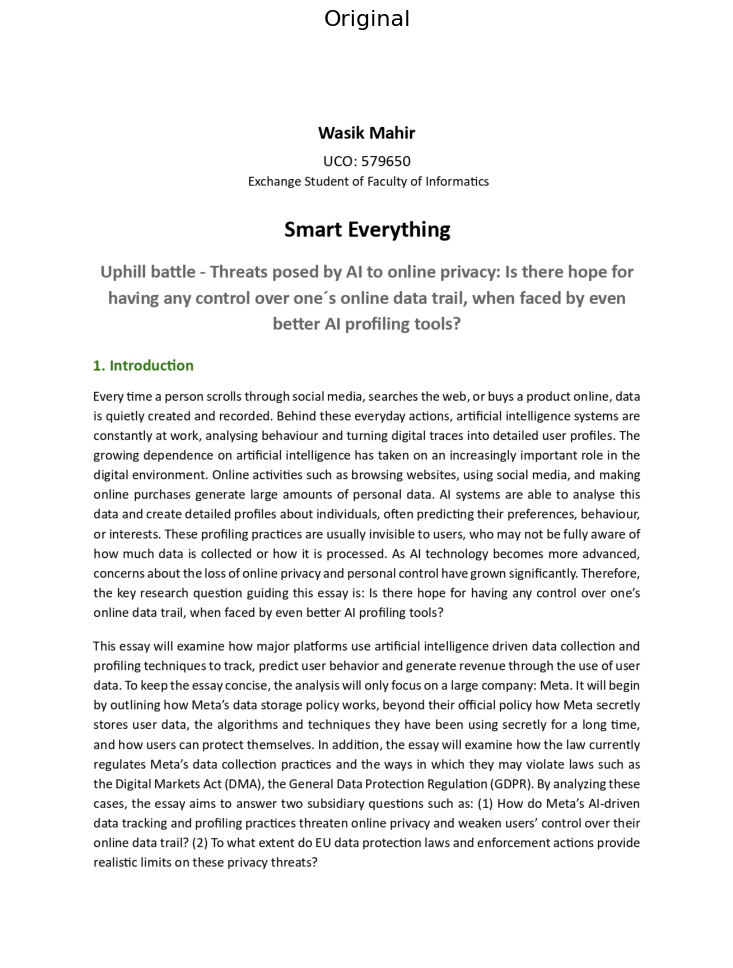

In [19]:
from PIL import Image
import matplotlib.pyplot as plt

noise_image_test = os.path.join(ENG_IMAGES_DIR,"1.jpg")

img = Image.open(noise_image_test).convert("RGB")

plt.figure(figsize=(10,12))
plt.imshow(img)
plt.title("Original", fontsize=16)
plt.axis("off")
plt.show()

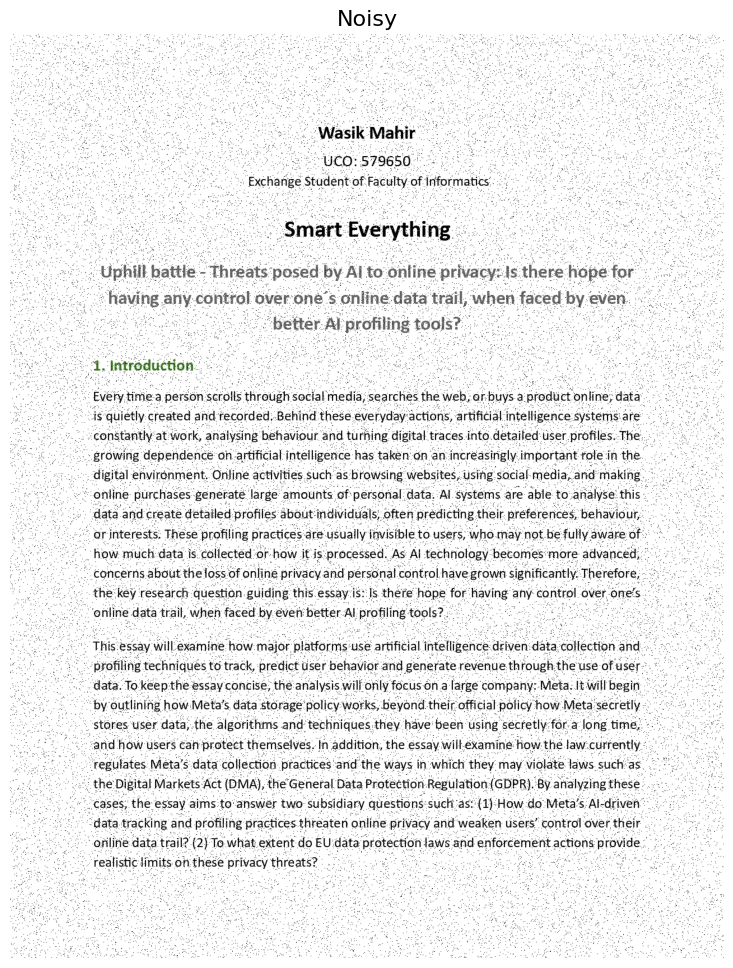

In [20]:
noisy_img = add_salt_pepper(img, amount=0.04,salt_vs_pepper=0.3)
plt.figure(figsize=(10,12))
plt.imshow(noisy_img)
plt.title("Noisy", fontsize=16)
plt.axis("off")
plt.show()

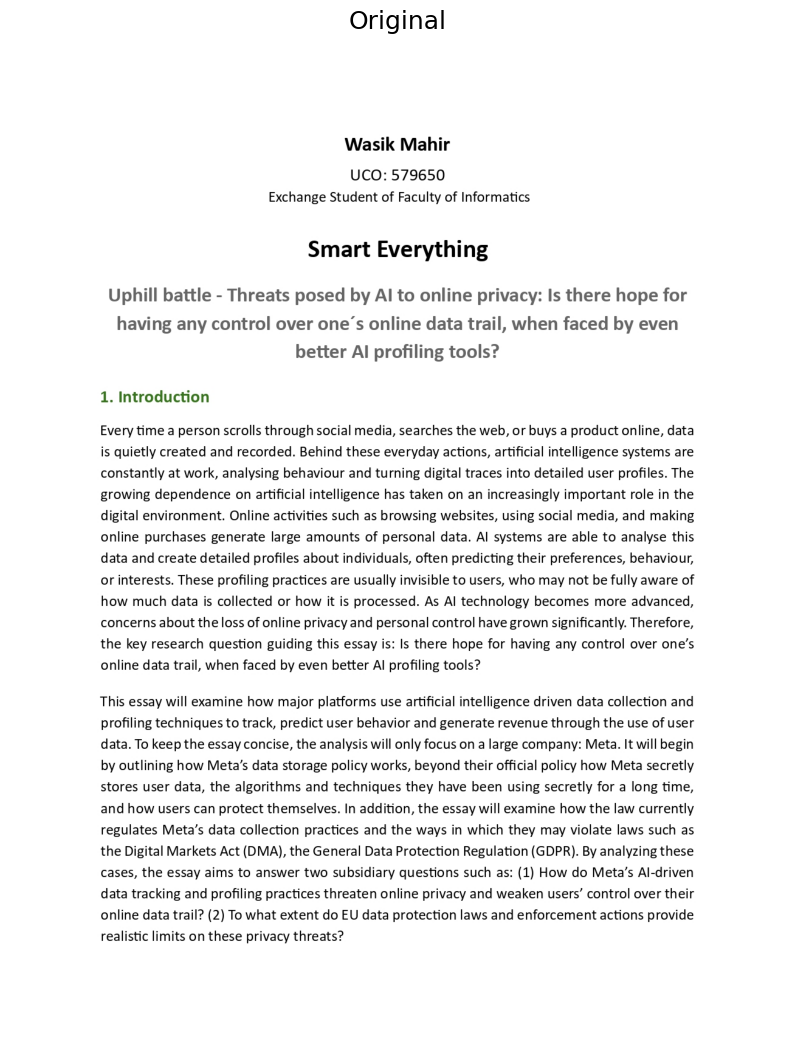

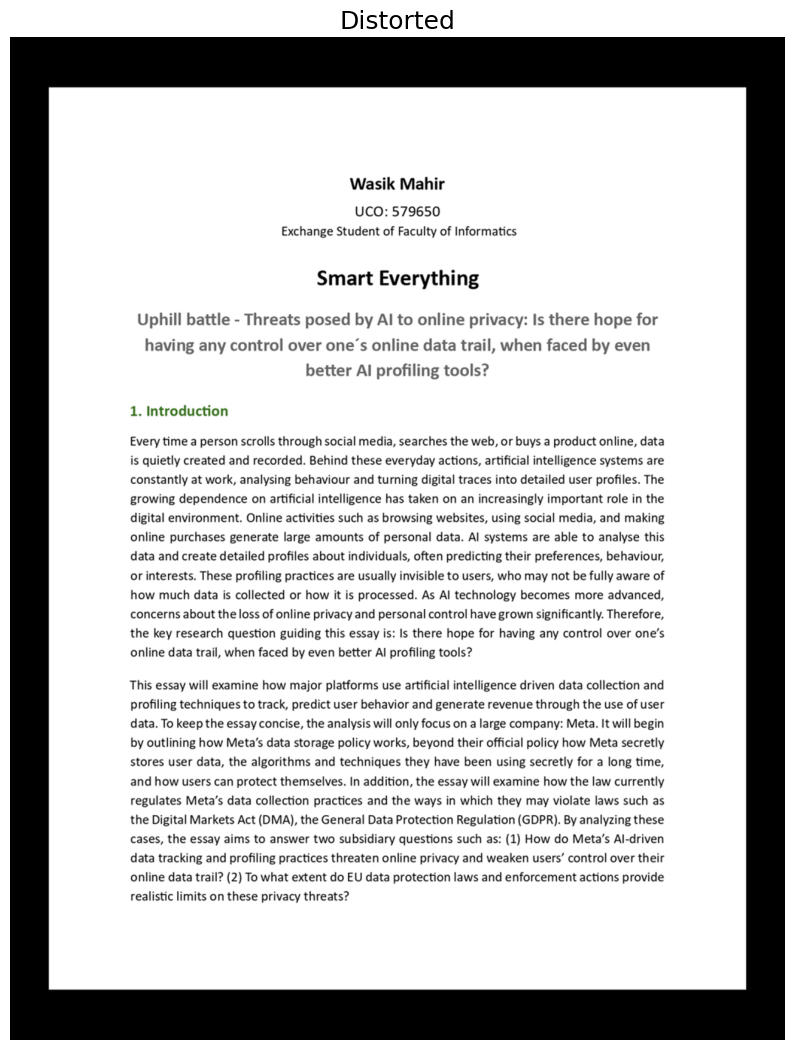

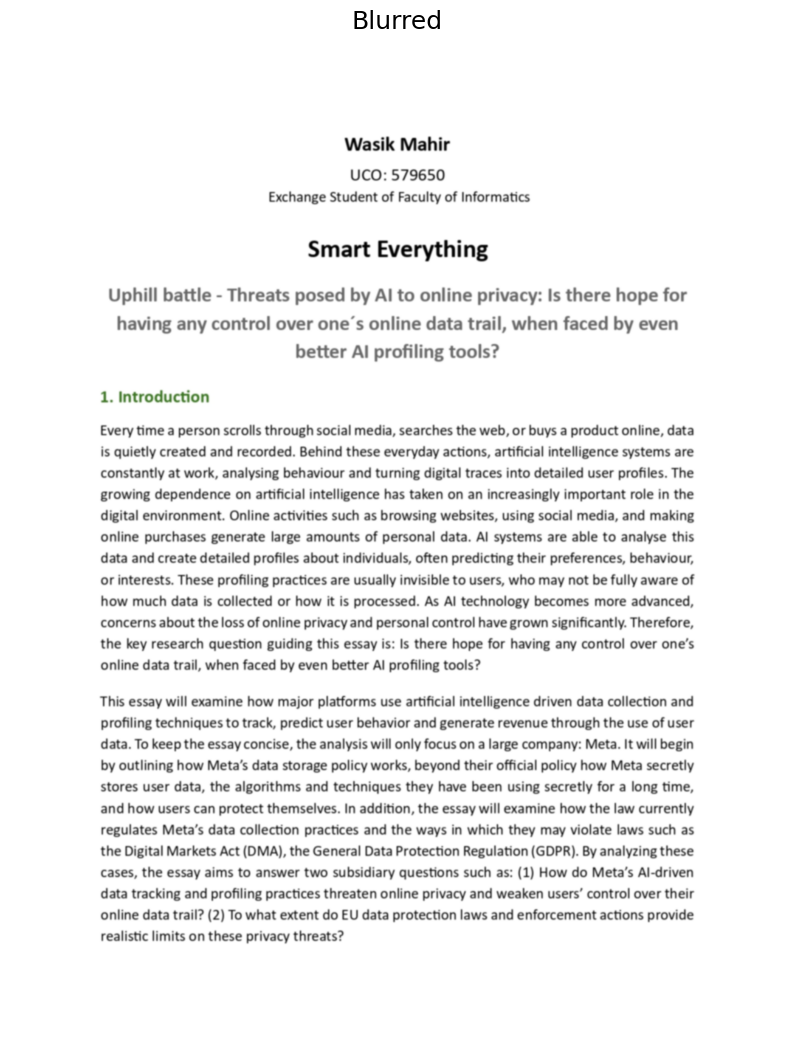

In [21]:
from PIL import Image
import matplotlib.pyplot as plt

noise_image_test2 = os.path.join(ENG_IMAGES_DIR,"1.jpg")
img1 = Image.open(noise_image_test2).convert("RGB")

#fixed zoom_scale
distorted_img = add_image_distortion(
    img1,
    zoom_scale=0.9,
    resolution_scale=0.8
)


blurred_img = add_blur(img1, kernel_size=5)

#original
plt.figure(figsize=(10,14))
plt.imshow(img1)
plt.title("Original", fontsize=18)
plt.axis("off")
plt.show()

#distorted
plt.figure(figsize=(10,14))
plt.imshow(distorted_img)
plt.title("Distorted", fontsize=18)
plt.axis("off")
plt.show()

#blur
plt.figure(figsize=(10,14))
plt.imshow(blurred_img)
plt.title("Blurred", fontsize=18)
plt.axis("off")
plt.show()

In [22]:
def apply_all_corruptions(image,sp_amount=0.005,sp_ratio=0.5,zoom_scale=1.15,resolution_scale=0.7,
                          blur_kernel=3):
    image = add_salt_pepper(
        image,
        amount=sp_amount,
        salt_vs_pepper=sp_ratio
    )

    image = add_image_distortion(
        image,
        zoom_scale=zoom_scale,
        resolution_scale=resolution_scale
    )

    image = add_blur(
        image,
        kernel_size=blur_kernel
    )

    return image

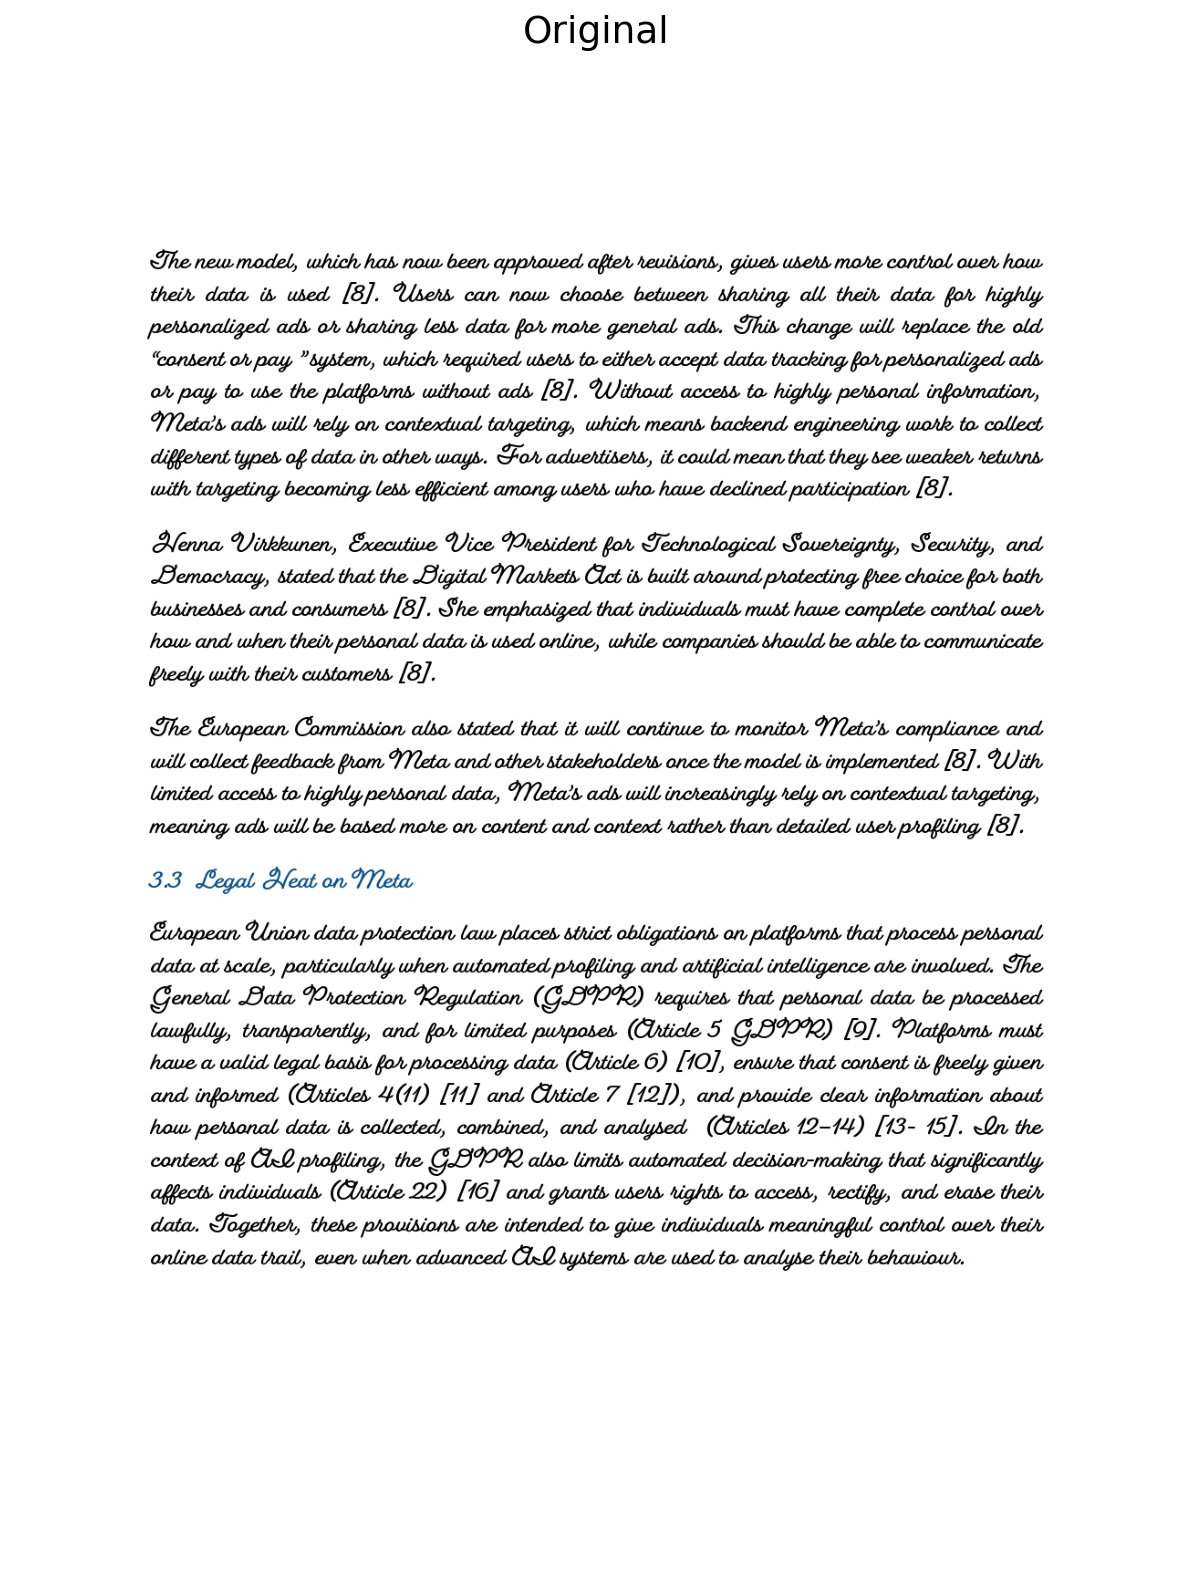

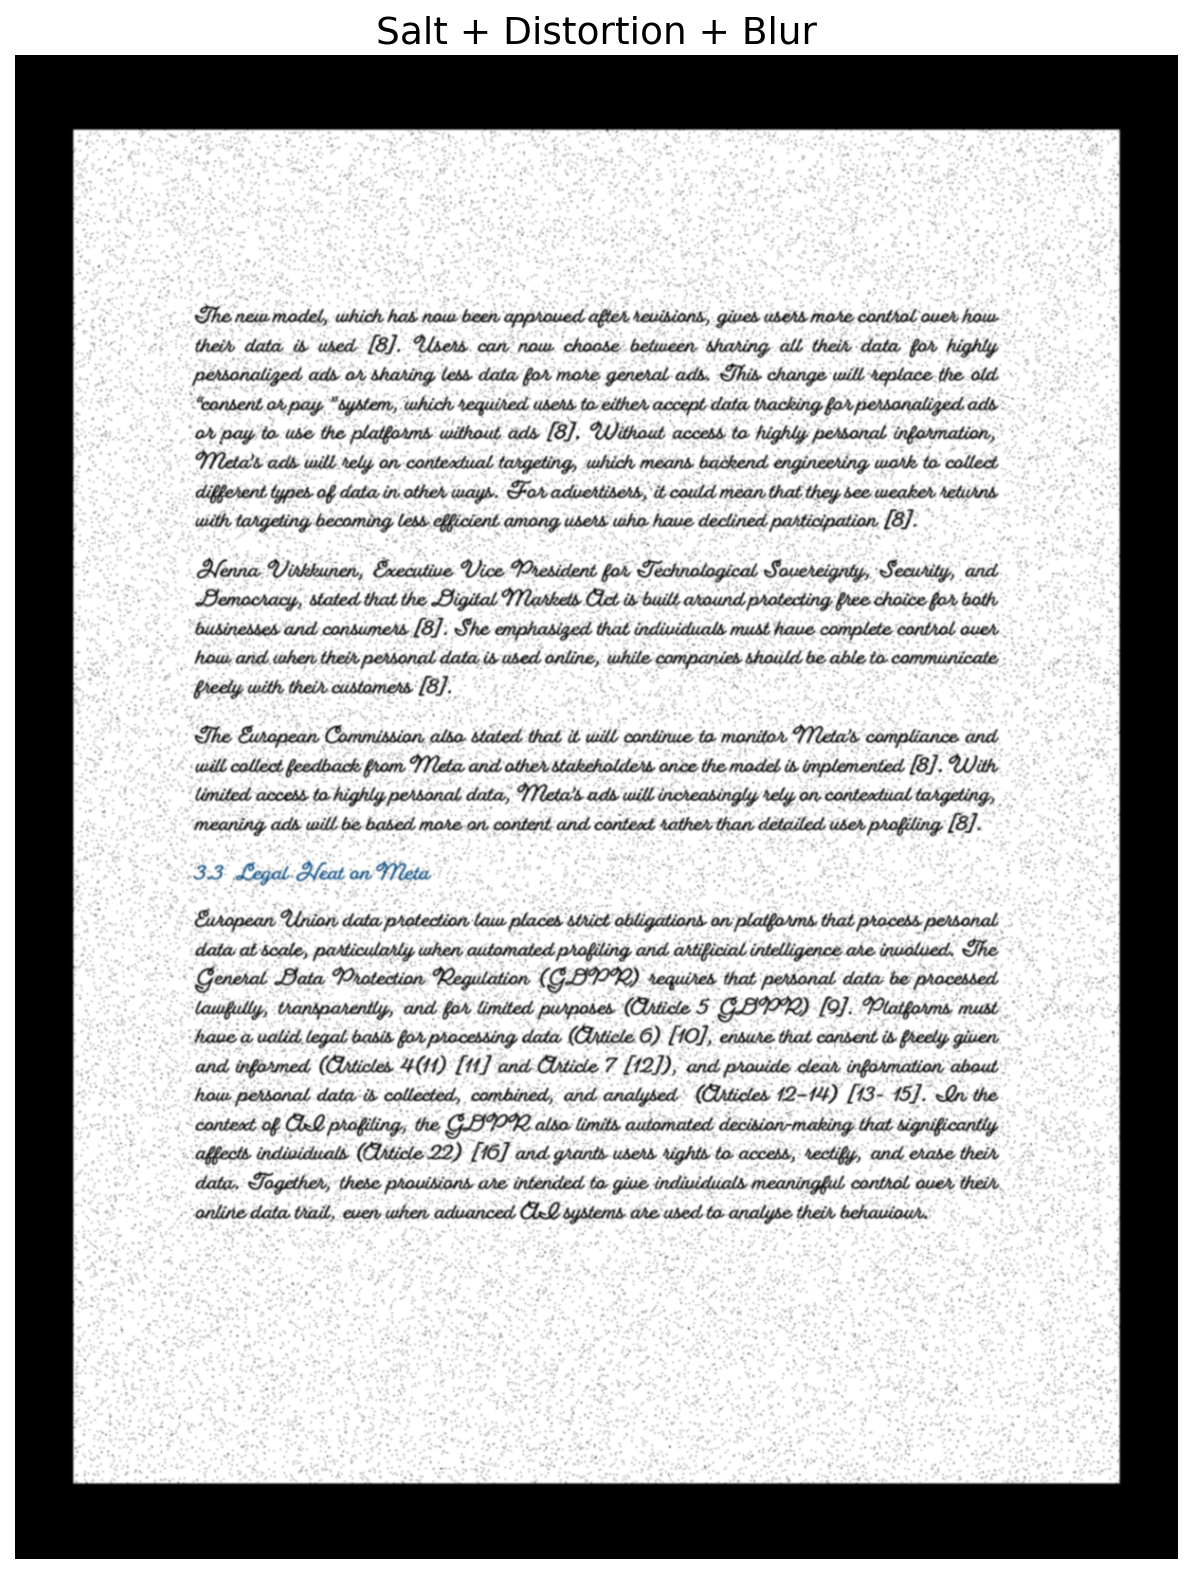

In [23]:
"""
sp_amount=0.05 ==  0.001 Very little noise, 0.05 very heavy 5% corrupted. 0.02 Heavy noise 2% corrupted,
sp_ratio=0.8 == 80% white dots, 20% black dots
zoom_scale=0.9  == Text shrinks or zoom out, 1.0 no shirnk, 1.5 zoom in
resolution_scale=1.0 == - 1.0 no quality loss, - 0.7 Noticeable blur,Thin letters begin disappearing -0.5 Heavy degradation.
blur_kernel=3, == 1 no blurr, 3 mild blurr, 5 moderate blurr, 7 strong blurr

"""
noise_image_test = os.path.join(ENG_IMAGES_DIR,"5.jpg")

img = Image.open(noise_image_test).convert("RGB")
combined_img = apply_all_corruptions(
    img,
    sp_amount=0.04,
    sp_ratio=0.4,
    zoom_scale=0.9,
    resolution_scale = 0.95,
    blur_kernel=3
)
#original
plt.figure(figsize=(10,14), dpi=150)
plt.imshow(img)
plt.title("Original", fontsize=18)
plt.axis("off")
plt.show()

#combined
plt.figure(figsize=(10,14), dpi=150)
plt.imshow(combined_img)
plt.title("Salt + Distortion + Blur", fontsize=18)
plt.axis("off")
plt.show()

In [24]:
import os
os.makedirs("corrupted_images", exist_ok=True)

In [25]:
pages = [1,2,3,4,5,6]

In [26]:
from PIL import Image

for p in pages:
    img = Image.open(
        os.path.join(ENG_IMAGES_DIR, f"{p}.jpg")
    ).convert("RGB")

    combined_img = apply_all_corruptions(
        img,
        sp_amount=0.04,
        sp_ratio=0.4,
        zoom_scale=0.9,
        resolution_scale = 0.95,
        blur_kernel=3
    )

    combined_img.save(f"corrupted_images/{p}.jpg")

print("Done saving all corrupted images.")

Done saving all corrupted images.


In [27]:
for p in pages:
    print("\n==============================")
    print(f"Page {p}")
    print("==============================")

    image_path = os.path.join(
        "corrupted_images",
        f"{p}.jpg"
    )

    output_path = os.path.join(
        output_dir_2,
        f"page_{p}.txt"
    )

    output_text = run_ocr_one_image(
        image_path,
        prompt_text_2
    )

    print(output_text)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(output_text)

    print(f"Saved: {output_path}")


Page 1
Wasik Mahir
UCO: 579650
Exchange Student of Faculty of Informatics

Smart Everything

Uphill battle - Threats posed by AI to online privacy: Is there hope for
having any control over one's online data trail, when faced by even
better AI profiling tools?

1. Introduction

Every time a person scrolls through social media, searches the web, or buys a product online, data
is quietly created and recorded. Behind these everyday actions, artificial intelligence systems are
constantly at work, analysing behaviour and turning digital traces into detailed user profiles. The
growing dependence on artificial intelligence has taken on an increasingly important role in the
digital environment. Online activities such as browsing websites, using social media, and making
online purchases generate large amounts of personal data. AI systems are able to analyse this
data and create detailed profiles about individuals, often predicting their preferences, behaviour,
or interests. These profiling pra

In [28]:
def normalize_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [31]:
results_exp2 = []

for p in pages:
    print(f"Evaluating Experiment 2 - page {p}...")

    gold_path = os.path.join(
        ENG_GOLD_DIR,
        f"{p}.txt"
    )

    with open(gold_path, "r", encoding="utf-8") as f:
        gold_text = f.read()

    pred_path = os.path.join(
        output_dir_2,
        f"page_{p}.txt"
    )

    with open(pred_path, "r", encoding="utf-8") as f:
        pred_text = f.read()

    gold_norm = normalize_text(gold_text)
    pred_norm = normalize_text(pred_text)

    # compute metrics
    wer_score = wer(gold_norm, pred_norm)
    cer_score = cer(gold_norm, pred_norm)

    results_exp2.append({
        "page": p,
        "WER": wer_score,
        "CER": cer_score
    })

Evaluating Experiment 2 - page 1...
Evaluating Experiment 2 - page 2...
Evaluating Experiment 2 - page 3...
Evaluating Experiment 2 - page 4...
Evaluating Experiment 2 - page 5...
Evaluating Experiment 2 - page 6...


In [33]:
print("=== Experiment 2 Results: Gemini - English ===")
df_exp2 = pd.DataFrame(results_exp2)
df_exp2

=== Experiment 2 Results: Gemini - English ===


,page,WER,CER
0,1,0.017722,0.002774
1,2,0.017094,0.002877
2,3,0.041394,0.006382
3,4,0.011494,0.001880
4,5,0.015306,0.002338
5,6,0.016667,0.002918


In [34]:
mean_wer = df_exp2["WER"].mean()
mean_cer = df_exp2["CER"].mean()

print("=== Experiment 2 Results - Gemini -English ===")
print(f"Mean WER: {mean_wer:.4f}")
print(f"Mean CER: {mean_cer:.4f}")

=== Experiment 2 Results - Gemini -English ===
Mean WER: 0.0199
Mean CER: 0.0032


In [36]:
import os

output_dir_result_1 = "outputs/Results"
os.makedirs(output_dir_result_1, exist_ok=True)

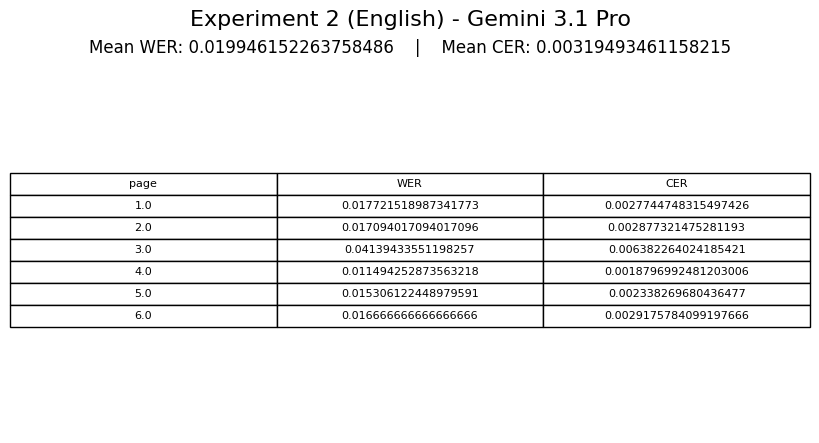

Saved: outputs/Results\experiment_2_results.png


In [37]:
import os
import matplotlib.pyplot as plt

mean_wer = df_exp2["WER"].mean()
mean_cer = df_exp2["CER"].mean()

save_path = os.path.join(output_dir_result_1, "experiment_2_results.png")

fig, ax = plt.subplots(figsize=(10, len(df_exp2) * 0.45 + 2))
ax.axis("off")


fig.suptitle("Experiment 2 (English) - Gemini 3.1 Pro", fontsize=16, y=0.98)

summary_text = f"Mean WER: {mean_wer}    |    Mean CER: {mean_cer}"
fig.text(0.5, 0.90, summary_text, ha="center", va="center", fontsize=12)


table = ax.table(
    cellText=df_exp2.values,
    colLabels=df_exp2.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.3)

ax.set_position([0.1, 0.08, 0.8, 0.78])

fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

print("Saved:", save_path)

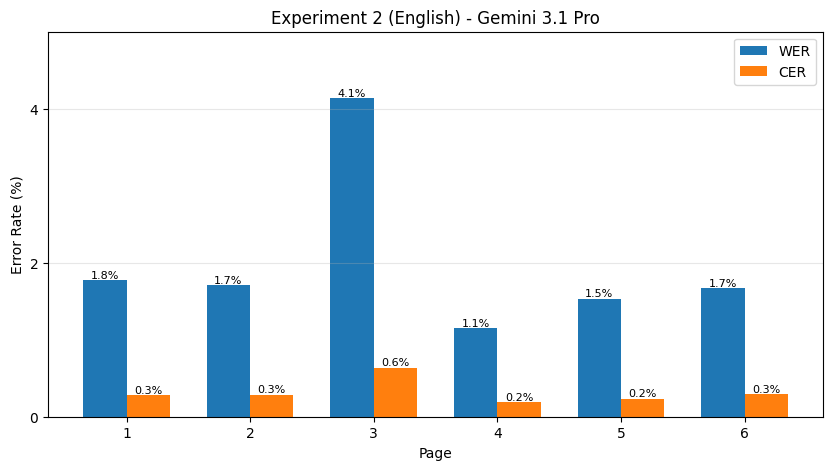

In [39]:
x = np.arange(len(df_exp2))
width = 0.35

wer_pct = df_exp2["WER"] * 100
cer_pct = df_exp2["CER"] * 100

plt.figure(figsize=(10,5))

bars1 = plt.bar(x - width/2, wer_pct, width, label="WER")
bars2 = plt.bar(x + width/2, cer_pct, width, label="CER")

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xticks(x, df_exp2["page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 2 (English) - Gemini 3.1 Pro")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 5)
plt.yticks(np.arange(0, 6, 2))

save_path = os.path.join(
    output_dir_result_1,
    "experiment_2_gemini_graph_results.pdf"
)

plt.savefig(save_path, bbox_inches="tight")
plt.show()